MODEL ARIMA

In [36]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import seaborn as sns
sns.set()
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from itertools import combinations
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import pmdarima as pm

from pandas.tseries.offsets import DateOffset

In [37]:
polusi = pd.read_csv('polusi5_1.csv')
polusi.isnull().sum()

Unnamed: 0     0
date_mks       0
pm25_mks       2
md_mks         2
IQR_mks        2
              ..
md_riau        2
IQR_riau       2
pm25_sorong    2
md_sorong      2
IQR_sorong     2
Length: 119, dtype: int64

In [38]:
DATA_INFO= pd.to_datetime(polusi['date_mks'])
date_time=pd.concat([DATA_INFO], axis=1)

In [39]:
date_time ['ds'] = date_time['date_mks'].astype(str) 

In [40]:
data= pd.DataFrame()
data['ds'] = pd.to_datetime(date_time ['ds'].astype(str))
data['y'] = polusi['IQR_jkt'].values
data.dropna()

,ds,y
1,2018-11-22,0.036
2,2018-12-01,0.037
3,2018-12-10,0.035
4,2018-12-19,0.031
5,2018-12-28,0.026
...,...,...
226,2024-05-30,0.034
227,2024-06-08,0.036
228,2024-06-17,0.030
229,2024-06-26,0.034


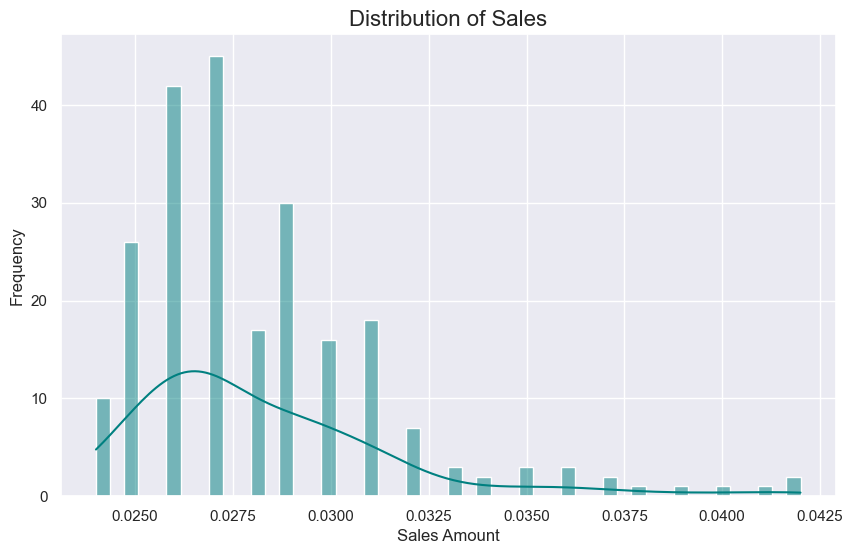

In [41]:
#  Sales Overview  
plt.figure(figsize=(10, 6))
sns.histplot(polusi['IQR_mks'], bins=50, kde=True, color='teal')
plt.title('Distribution of Sales', fontsize=16)
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

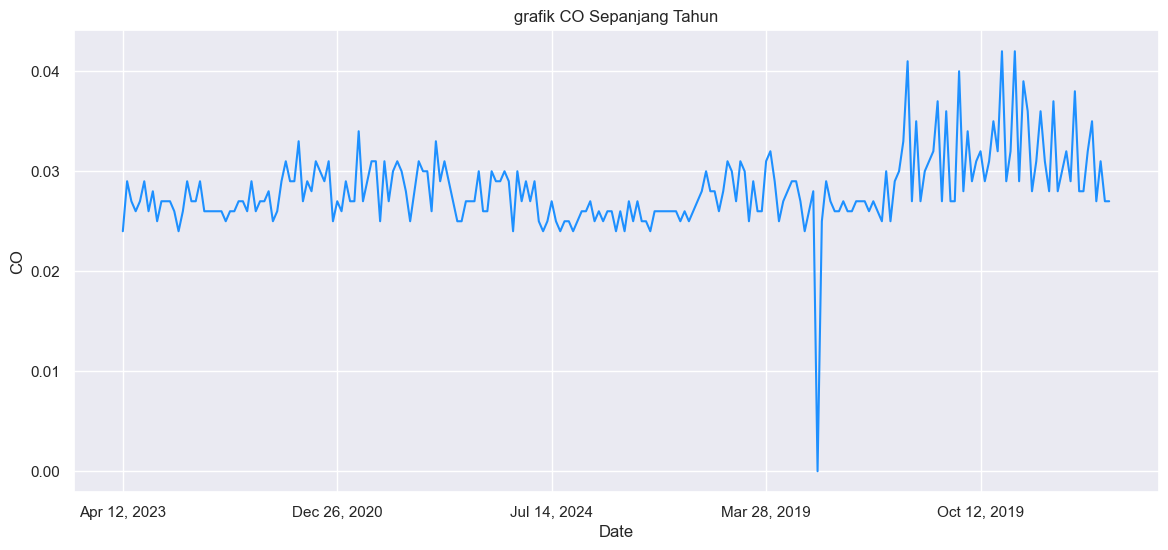

In [42]:
#  Convert date to datetime format
polusi['date'] = pd.to_datetime(date_time['date_mks'])

#  Plot: Overall Sales Trend Over Time
plt.figure(figsize=(14, 6))
polusi.groupby('date_mks')['IQR_mks'].sum().plot(title='grafik CO Sepanjang Tahun', color='dodgerblue')
plt.xlabel('Date')
plt.ylabel('CO')
plt.grid(True)
plt.show()

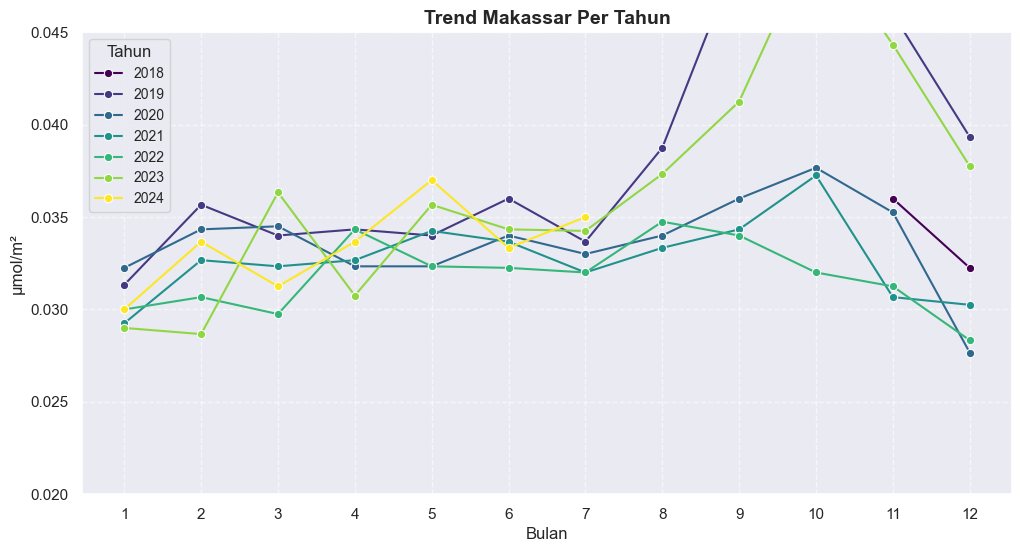

In [43]:
polusi = pd.DataFrame(data)

#Atur Y sama dengan grafik lain
y_min, y_max = 0.020, 0.045

# Pastikan kolom 'y' bersifat numerik
polusi['y'] = pd.to_numeric(polusi['y'], errors='coerce')

# Konversi kolom 'ds' ke format datetime
polusi['ds'] = pd.to_datetime(polusi['ds'], errors='coerce')

# Ekstrak Bulan dan Tahun dari kolom 'ds'
polusi['month'] = polusi['ds'].dt.month
polusi['year'] = polusi['ds'].dt.year

# Agregasi data berdasarkan tahun dan bulan (misalnya, rata-rata nilai)
monthly_sales = polusi.groupby(['year', 'month'])['y'].mean().reset_index()

# Plot: Tren Bulanan Sepanjang Tahun

plt.figure(figsize=(12, 6))
plt.ylim(y_min,y_max)
sns.lineplot(data=monthly_sales, x='month', y='y', hue='year', palette='viridis', marker="o")
plt.title('Trend Makassar Per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('µmol/m²', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Tahun', loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [44]:
def test_stationarity(timeseries):
    #Determing rolling statistics
    MA = timeseries.rolling(window=12).mean()
    MSTD = timeseries.rolling(window=12).std()

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(MA, color='red', label='Rolling Mean')
    std = plt.plot(MSTD, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [45]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

In [46]:
# Konversi kolom 'date_mks' ke datetime dan simpan di kolom 'ds'
data['date_mks'] = pd.to_datetime(data['ds'])

# Hapus kolom 'date_mks'
data = data.drop(columns='ds')

# Set kolom 'ds' sebagai index
data = data.set_index('date_mks')

# Ubah nama kolom '#y' menjadi 'y'
data = data.rename(columns={'#y': 'y'})


#data = data[~data['y'].isin([0.061, 0.053, 0.054, 0.046, 0.047,0.048, 0.049, 0.049, 0.05, 0.47, 0.048, 0.049])]
data = data.dropna()

In [47]:
# Membuat DataFrame
df = pd.DataFrame(data)

# Membuat dan melatih model IsolationForest
model = IsolationForest(contamination=0.1)  # Set contamination sesuai dengan ekspektasi proporsi outlier
df['y'] = df['y'].values.reshape(-1, 1)  # Mengubah format data untuk kompatibilitas dengan model
model.fit(df[['y']])

# Memprediksi outlier
df['anomaly'] = model.predict(df[['y']])

# Identifikasi outlier (1 = inlier, -1 = outlier)
outliers = df[df['anomaly'] == -1]

# Menghitung rata-rata dari nilai non-outlier
mean_value = df[df['anomaly'] == 1]['y'].mean()

# Mengganti nilai outlier dengan rata-rata
df.loc[df['anomaly'] == -1, 'y'] = mean_value

# Menghapus kolom tambahan
df = df.drop(columns=['anomaly'])
df.head(10)

,y
date_mks,
2018-11-22,0.036000
2018-12-01,0.037000
2018-12-10,0.035000
2018-12-19,0.031000
2018-12-28,0.033505
2019-01-06,0.034000
2019-01-15,0.031000
2019-01-24,0.029000
2019-02-02,0.036000


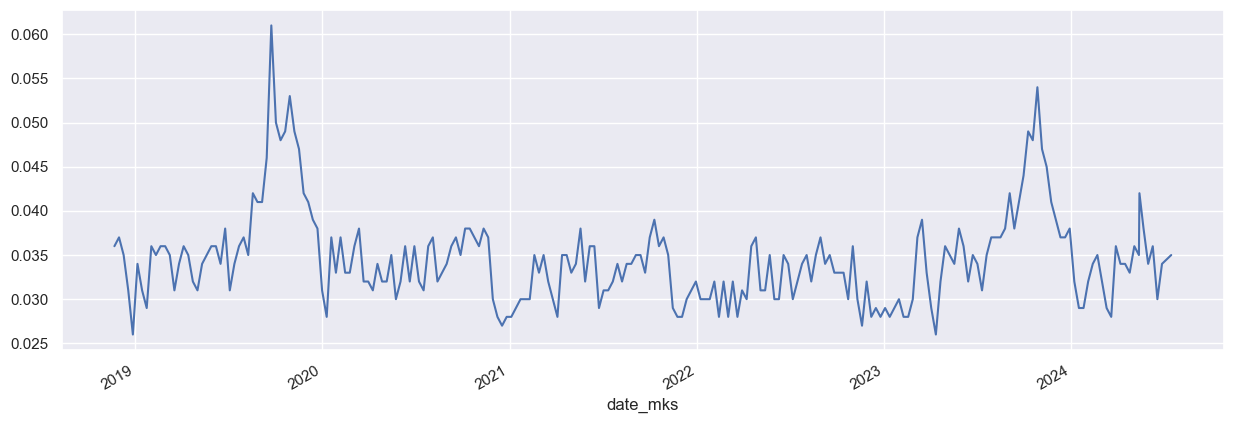

In [48]:
plt.figure(figsize = (15,5))
data['y'].plot();

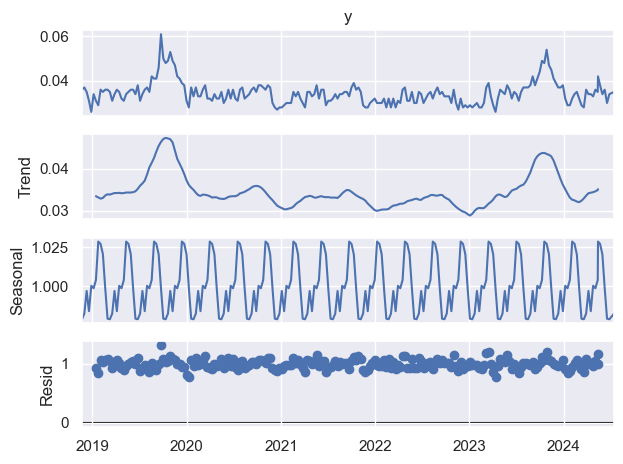

In [49]:
dec = sm.tsa.seasonal_decompose(data['y'],period = 12, model = 'multiplicative').plot()
plt.show()

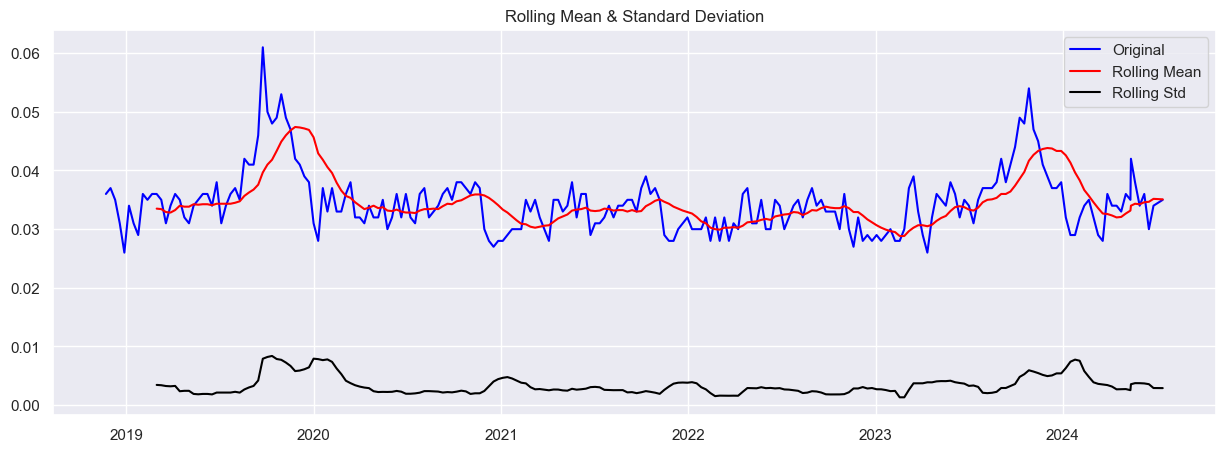

Results of Dickey-Fuller Test:
Test Statistic                  -3.709513
p-value                          0.003981
#Lags Used                       2.000000
Number of Observations Used    227.000000
Critical Value (1%)             -3.459490
Critical Value (5%)             -2.874358
Critical Value (10%)            -2.573602
dtype: float64


In [50]:
ts = test_stationarity(data['y'])

In [ ]:
###KORELASI ANTARA DATA AKTUAL DAN ROLLING MEAN

#Masukkan Data
window_size = 12 
original = data['y']
rolling = original.rolling(window=window_size).mean()

# Drop NaN agar panjangnya sama
combined = pd.concat([original, rolling], axis=1).dropna()
combined.columns = ['original', 'rolling_mean']

# Hitung korelasi
correlation = combined['original'].corr(combined['rolling_mean'])
print(f"Korelasi antara original dan rolling mean: {correlation}")

Korelasi antara original dan rolling mean: 0.5826259977731575


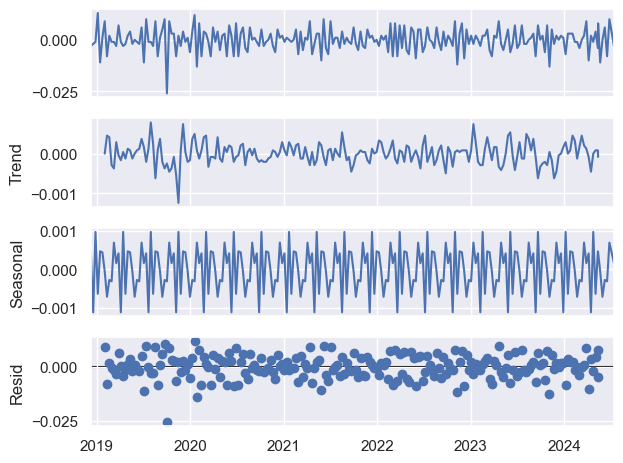

In [52]:
data_diff = data.diff().diff()
data_diff = data_diff.dropna()

dec = sm.tsa.seasonal_decompose(data_diff,period = 12).plot()
plt.show()

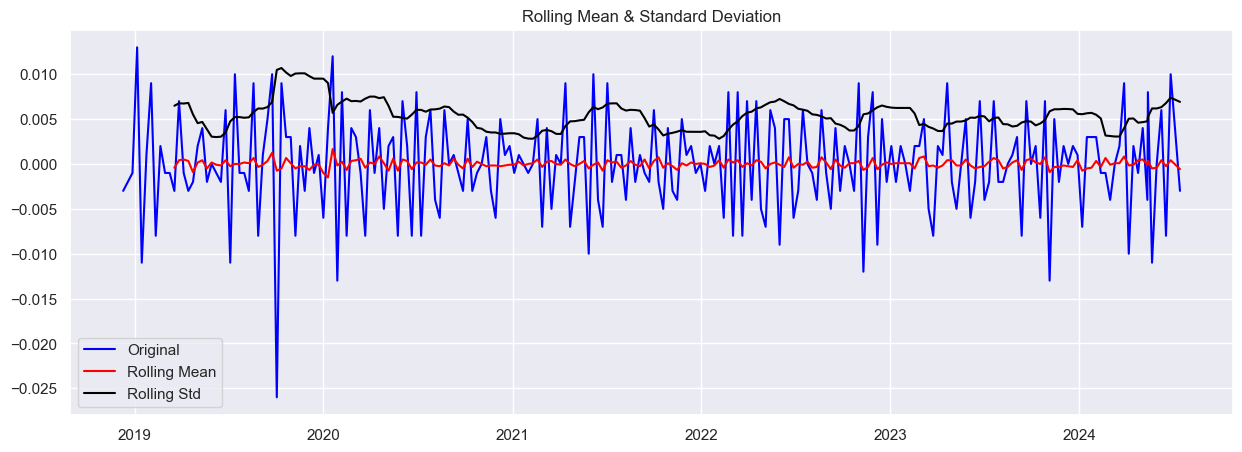

Results of Dickey-Fuller Test:
Test Statistic                -7.223717e+00
p-value                        2.079184e-10
#Lags Used                     1.100000e+01
Number of Observations Used    2.160000e+02
Critical Value (1%)           -3.460992e+00
Critical Value (5%)           -2.875016e+00
Critical Value (10%)          -2.573952e+00
dtype: float64


In [53]:
test_stationarity(data_diff)

In [54]:
def test_stationarity(timeseries, window=12):
    print(f"\nData length: {len(timeseries)}")
    print(f"NaN values: {timeseries.isnull().sum()}")

    # Rolling stats
    rolmean = timeseries.rolling(window=window).mean()
    rolstd = timeseries.rolling(window=window).std()

    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.grid()
    plt.show(block=True)

    # ADF test
    print('\nResults of Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)


Data length: 228
NaN values: y    0
dtype: int64


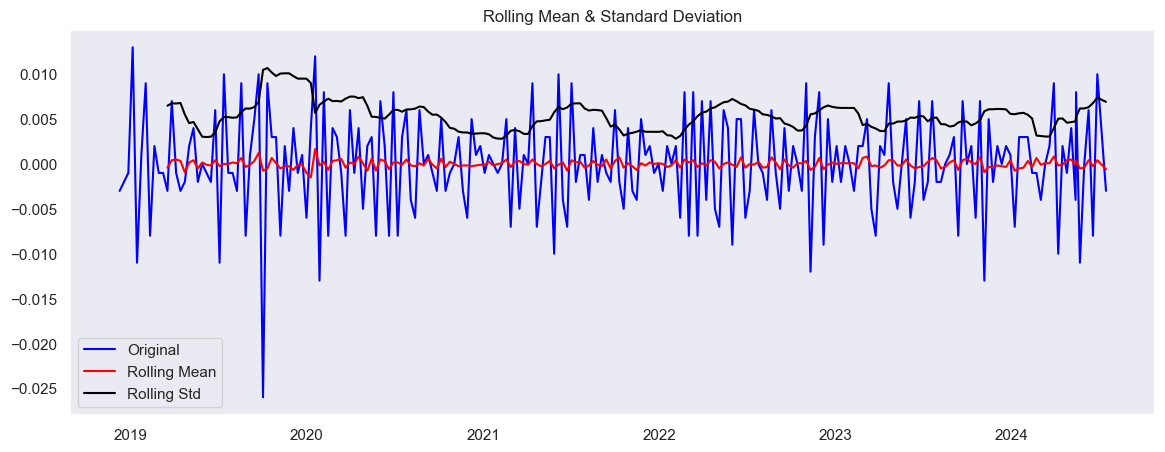


Results of Augmented Dickey-Fuller Test:
ADF Statistic                 -7.223717e+00
p-value                        2.079184e-10
#Lags Used                     1.100000e+01
Number of Observations Used    2.160000e+02
Critical Value (1%)           -3.460992e+00
Critical Value (5%)           -2.875016e+00
Critical Value (10%)          -2.573952e+00
dtype: float64


In [55]:
test_stationarity(data_diff)

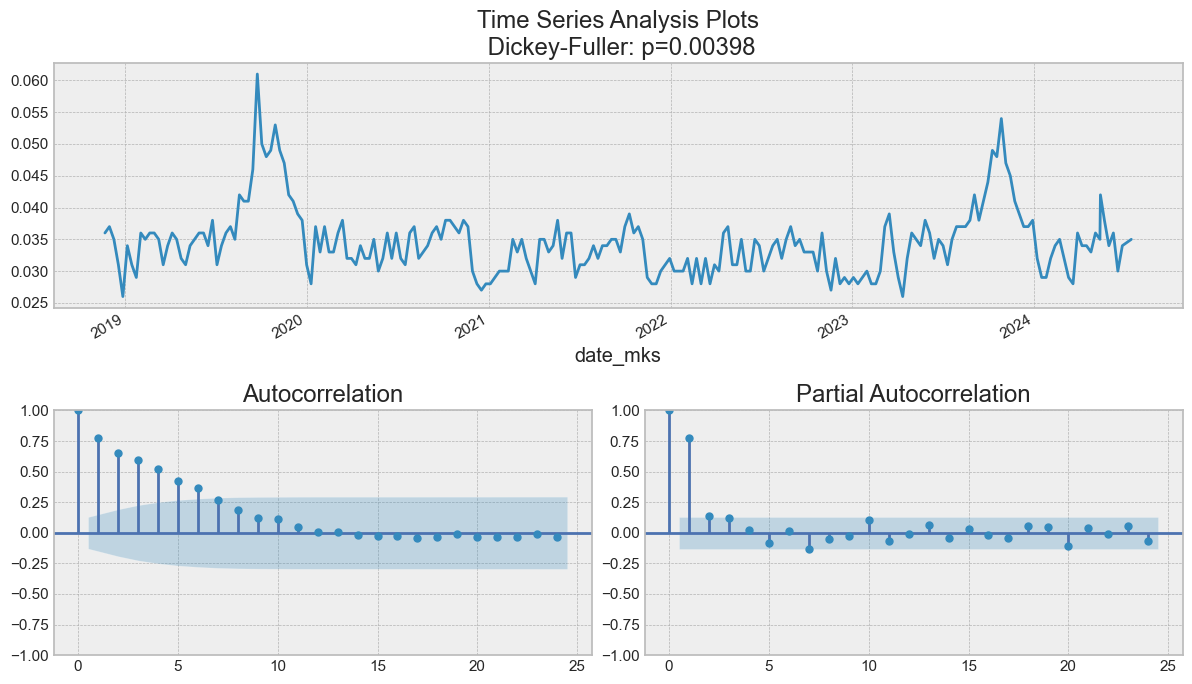

In [56]:
tsplot(data['y'])

In [57]:
from statsmodels.graphics.tsaplots import plot_pacf
from pmdarima.arima import auto_arima
import matplotlib.pyplot as plt

# Auto ARIMA
auto_model = auto_arima(data['y'], seasonal=False, trace=True, suppress_warnings=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1957.364, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-889.005, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1164.350, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1959.709, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-1378.257, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1958.121, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-1957.697, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-1491.152, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-1937.170, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-1949.651, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-1973.828, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-1922.239, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-1974.781, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] in

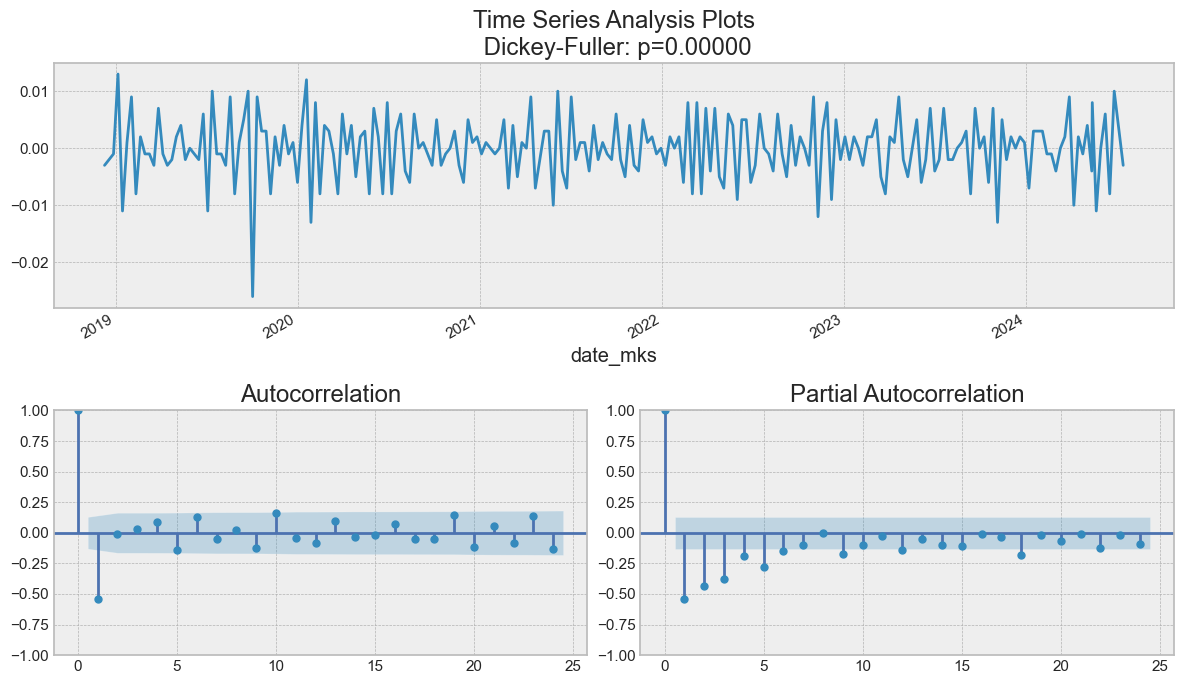

In [58]:
tsplot(data_diff['y'])

In [59]:
model = ARIMA(data['y'],order = (2,1,2))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  230
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 981.094
Date:                Mon, 19 May 2025   AIC                          -1952.187
Time:                        20:48:21   BIC                          -1935.019
Sample:                             0   HQIC                         -1945.261
                                - 230                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4286      0.471     -0.909      0.363      -1.353       0.495
ar.L2          0.0119      0.281      0.042      0.966      -0.540       0.563
ma.L1          0.1455      0.455      0.320      0.7

In [60]:
size = int(len(data) - 30)
train, test = data['y'][0:size], data['y'][size:len(data)]

print('\t ARIMA MODEL : In-Sample Forecasting \n')

history = list(train)
predictions = []

for t in range(len(test)):
    # Buat model ARIMA dengan data history yang ada
    model = ARIMA(history, order=(2, 1, 2))
    
    # Hapus parameter disp=0 jika tidak didukung di versi statsmodels yang Anda gunakan
    model_fit = model.fit()
    
    # Lakukan prediksi satu langkah ke depan
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(float(yhat))
    
    # Dapatkan observasi aktual dari data test
    obs = test[t]
    history.append(obs)
    
    print('predicted = %f, expected = %f' % (yhat, obs))


	 ARIMA MODEL : In-Sample Forecasting 

predicted = 0.046964, expected = 0.054000
predicted = 0.052358, expected = 0.047000
predicted = 0.047660, expected = 0.045000
predicted = 0.047144, expected = 0.041000
predicted = 0.042551, expected = 0.039000
predicted = 0.040742, expected = 0.037000
predicted = 0.038036, expected = 0.037000
predicted = 0.037558, expected = 0.038000
predicted = 0.037779, expected = 0.032000
predicted = 0.033531, expected = 0.029000
predicted = 0.031028, expected = 0.029000
predicted = 0.029590, expected = 0.032000
predicted = 0.031319, expected = 0.034000
predicted = 0.032916, expected = 0.035000
predicted = 0.034314, expected = 0.032000
predicted = 0.032484, expected = 0.029000
predicted = 0.030332, expected = 0.028000
predicted = 0.028882, expected = 0.036000
predicted = 0.034290, expected = 0.034000
predicted = 0.032936, expected = 0.034000
predicted = 0.034262, expected = 0.033000
predicted = 0.032992, expected = 0.036000
predicted = 0.035502, expected = 0.0

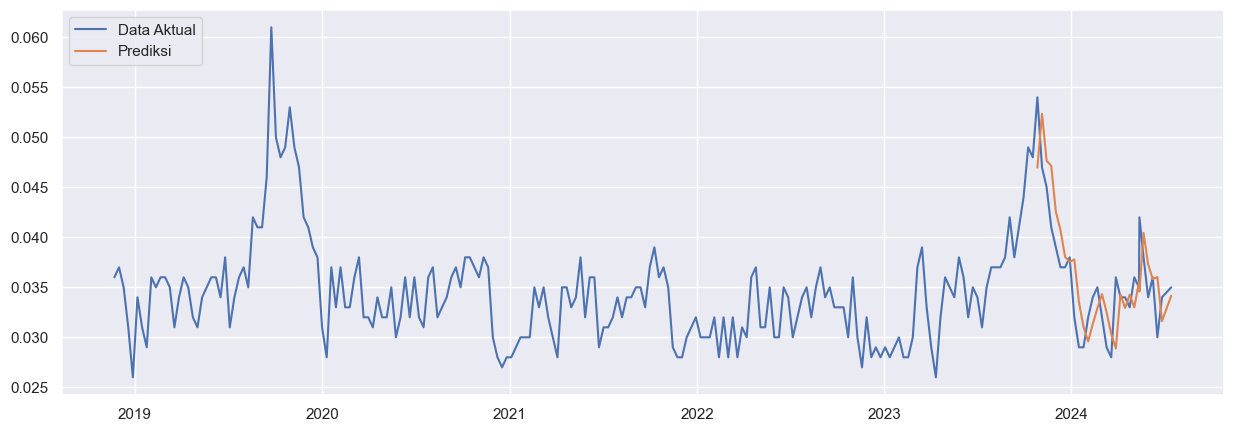

In [61]:
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(data['y'],label = 'Data Aktual')
plt.plot(predictions_series,label = 'Prediksi');
plt.legend(loc="upper left")
plt.show()

In [62]:
error = np.sqrt(mean_squared_error(test,predictions))
print('Test RMSE: %.4f' % error)

Test RMSE: 0.0038


In [63]:
future_dates = [data.index[-1] + DateOffset(weeks = x) for x in range(0,49)]

# New dataframe for storing the future values
df1 = pd.DataFrame(index = future_dates[1:],columns = data.columns)

forecast = pd.concat([data,df1])
forecast['ARIMA_Forecast_Function'] = np.NaN
forecast['ARIMA_Predict_Function'] = np.NaN
forecast.head()

,y,ARIMA_Forecast_Function,ARIMA_Predict_Function
2018-11-22,0.036,NaN,NaN
2018-12-01,0.037,NaN,NaN
2018-12-10,0.035,NaN,NaN
2018-12-19,0.031,NaN,NaN
2018-12-28,0.026,NaN,NaN


In [64]:
forecast['SARIMA_Forecast_Function'] = np.NaN
forecast['SARIMA_Predict_Function'] = np.NaN
forecast.head()

,y,ARIMA_Forecast_Function,ARIMA_Predict_Function,SARIMA_Forecast_Function,SARIMA_Predict_Function
2018-11-22,0.036,NaN,NaN,NaN,NaN
2018-12-01,0.037,NaN,NaN,NaN,NaN
2018-12-10,0.035,NaN,NaN,NaN,NaN
2018-12-19,0.031,NaN,NaN,NaN,NaN
2018-12-28,0.026,NaN,NaN,NaN,NaN


In [65]:
SARIMA_history_f = [x for x in train]
f3 = []

for t in (range(len(df1))):
    
    model = sm.tsa.statespace.SARIMAX(SARIMA_history_f,order = (2,1,2),seasonal_order = (0,1,1,12))
    model_fit = model.fit()
    
    output = model_fit.forecast()[0]
    
    SARIMA_history_f.append(output)
    f3.append(output)
    
for i in range(len(f3)):
    forecast.iloc[144 + i,3] = f3[i]
forecast.tail()

,y,ARIMA_Forecast_Function,ARIMA_Predict_Function,SARIMA_Forecast_Function,SARIMA_Predict_Function
2025-05-18,NaN,NaN,NaN,NaN,NaN
2025-05-25,NaN,NaN,NaN,NaN,NaN
2025-06-01,NaN,NaN,NaN,NaN,NaN
2025-06-08,NaN,NaN,NaN,NaN,NaN
2025-06-15,NaN,NaN,NaN,NaN,NaN


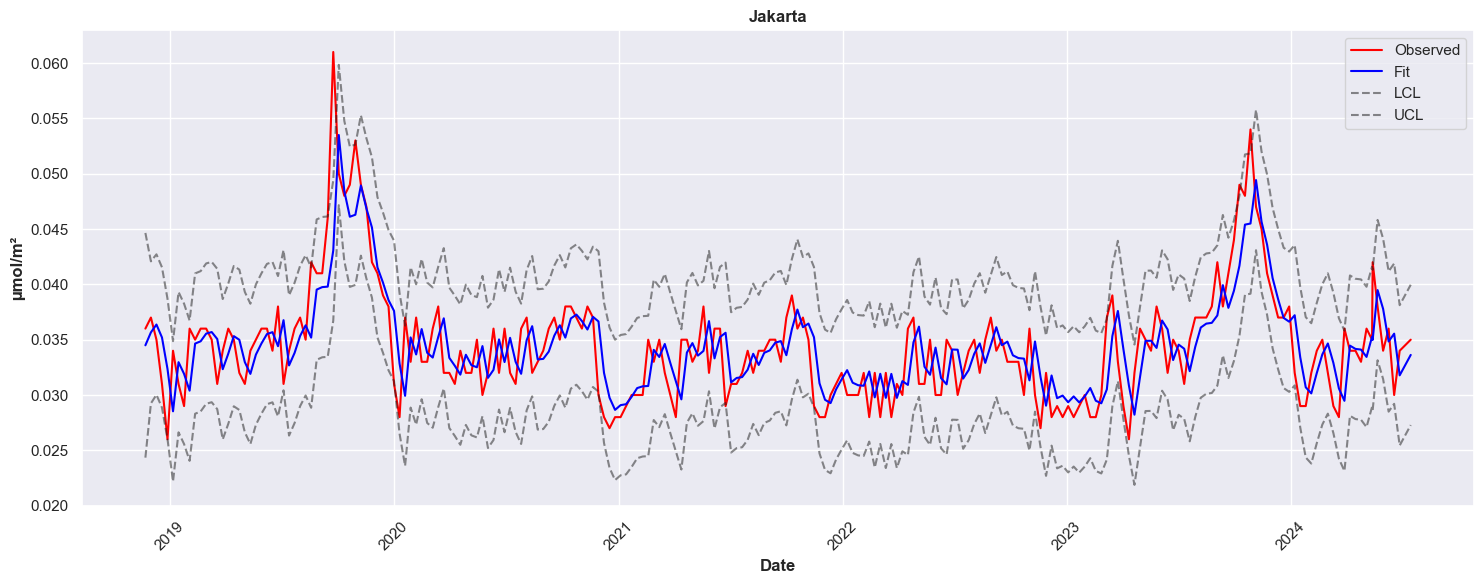

In [66]:
# ==== 1. Fit Model ====
model = ARIMA(data['y'], order=(1,0,1)) 
fitted_model = model.fit()

# ==== 2. Prediksi dan Konfiden Interval ====
pred = fitted_model.get_prediction(start=0, end=len(data)-1)
pred_mean = pred.predicted_mean
conf_int = pred.conf_int()  

# ==== 3. Plot ====
plt.figure(figsize=(15,6))
plt.plot(data.index, data['y'], color='red', label='Observed')             # Data aktual
plt.plot(data.index, pred_mean, color='blue', label='Fit')                 # Prediksi model
plt.plot(data.index, conf_int.iloc[:, 0], 'k--', alpha=0.5, label='LCL')   # Lower bound
plt.plot(data.index, conf_int.iloc[:, 1], 'k--', alpha=0.5, label='UCL')   # Upper bound


# Format
plt.xlabel("Date", fontsize=12, weight='bold')
plt.ylabel("µmol/m²", fontsize=12, weight='bold')
plt.title("Jakarta", weight='bold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


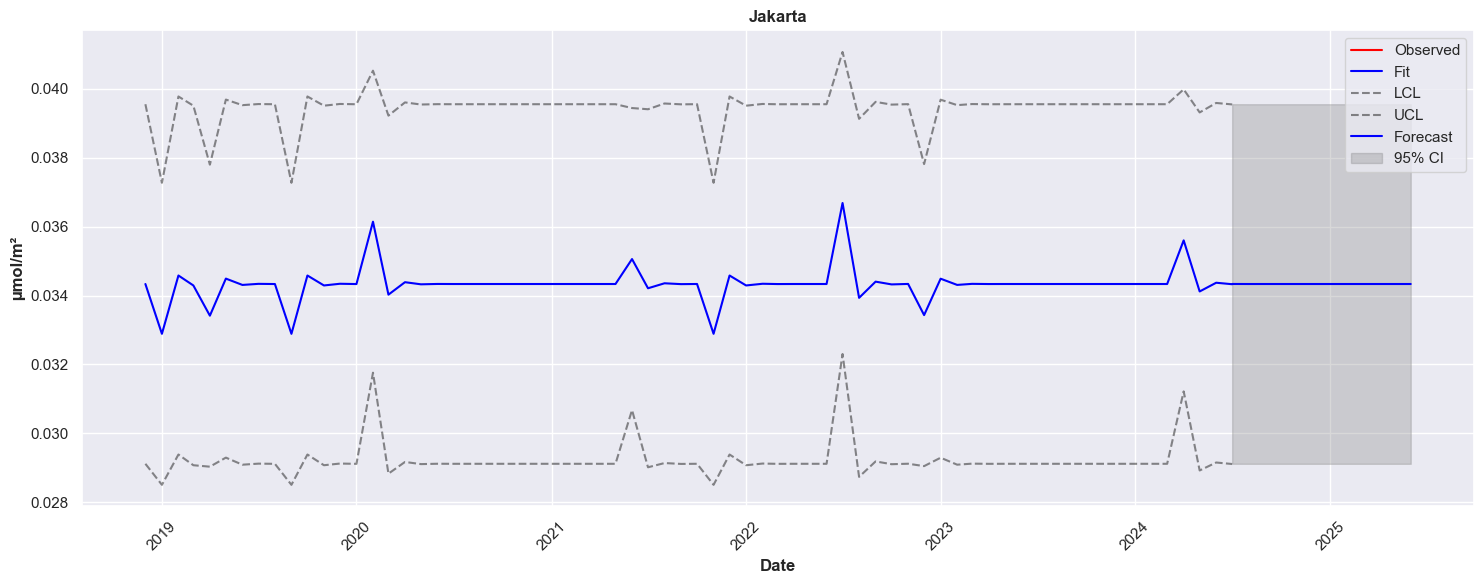

In [ ]:
# ==== 1. Fit Model ====
model = ARIMA(data['y'], order=(1,0,1)) 
fitted_model = model.fit()

# ==== 2. Prediksi dan Konfiden Interval ====
pred = fitted_model.get_prediction(start=0, end=len(data)-1)
pred_mean = pred.predicted_mean
conf_int = pred.conf_int()  

# ==== 3.prediksi 
steps_ahead = 12
forecast = fitted_model.get_forecast(steps=steps_ahead)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# === Buat model
last_date = data.index[-2]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=steps_ahead, freq='MS')

# ==== 3. Plot ====
plt.figure(figsize=(15,6))
plt.plot(data.index, data['y'], color='red', label='Observed')             
plt.plot(data.index, pred_mean, color='blue', label='Fit')                 
plt.plot(data.index, conf_int.iloc[:, 0], 'k--', alpha=0.5, label='LCL') 
plt.plot(data.index, conf_int.iloc[:, 1], 'k--', alpha=0.5, label='UCL')   
plt.plot(forecast_index, forecast_mean, color='blue', label='Forecast')
plt.fill_between(forecast_index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='gray', alpha=0.3, label='95% CI')


# Format
plt.xlabel("Date", fontsize=12, weight='bold')
plt.ylabel("µmol/m²", fontsize=12, weight='bold')
plt.title("Jakarta", weight='bold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [69]:
# Seasonal - fit stepwise auto-ARIMA
smodel = pm.auto_arima(data, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-1796.804, Time=0.58 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-1515.647, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-1756.666, Time=0.61 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-1722.238, Time=0.85 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-1517.616, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-1701.395, Time=0.08 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-1773.691, Time=1.63 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=2.31 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-1761.584, Time=1.06 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-1810.571, Time=2.38 sec
 ARIMA(1,0,1)(2,1,2)[12] intercept   : AIC=-1793.046, Time=3.59 sec
 ARIMA(1,0,1)(2,1,1)[12] intercept   : AIC=-1786.398, Time=2.84 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=-1727.897, Time=3.98 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=-1806.979, Time=4.25 sec
 ARIMA(2,0,

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  230
Model:             SARIMAX(1, 0, 1)x(1, 1, [1, 2], 12)   Log Likelihood                 912.286
Date:                                 Mon, 19 May 2025   AIC                          -1810.571
Time:                                         20:50:40   BIC                          -1786.880
Sample:                                              0   HQIC                         -1801.002
                                                 - 230                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.469e-05      0.000     -0.146      0.884      -0.000       0.000
ar.L1          0.8258      0.054     15.207      0.000       0.719       0.932
ma.L1         -0.1558      0.092     -1.689      0.091      -0.337       0.025
ar.S.L12      -0.5528      0.953     -0.580      0.562      -2.420       1.315
ma.S.L12      -0.1757      0.936     -0.188      0.851      -2.011       1.659
ma.S.L24      -0.4617      0.689     -0.671      0.503      -1.811       0.888
sigma2      1.286e-05   1.26e-06     10.214      0.000    1.04e-05    1.53e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                25.95
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.69   Skew:                             0.41
Prob(H) (two-sided):                  0.12   Kurtosis:                         4.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [70]:
data = data.dropna()
# Pastikan tidak ada NaN
data['y'] = data['y'].interpolate()
data = data.asfreq('MS')  # Tetapkan frekuensi bulanan

# Jalankan SARIMA
smodel = pm.auto_arima(data['y'], seasonal=True, m=12, D=1,
                       stepwise=True, suppress_warnings=True, trace=True)

# Pastikan index datetime
data.index = pd.to_datetime(data.index)
data = data.asfreq('MS')  # Sesuaikan frekuensi

# === Auto SARIMA ===
smodel = pm.auto_arima(data['y'],  order=(0,2,0),    # Gunakan hanya kolom target
                       start_p=1, start_q=1,
                       test='adf',
                       max_p=3, max_q=3, m=12,     # m=12 untuk bulanan
                       start_P=0, seasonal=True,
                       d=None, D=1, trace=True,
                       error_action='ignore',
                       suppress_warnings=True,
                       stepwise=True)

# Forecast
n_periods = 24
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
forecast_index = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1),
                               periods=n_periods, freq='MS')

# Series untuk plot
fitted_series = pd.Series(fitted, index=forecast_index)
lower_series = pd.Series(confint[:, 0], index=forecast_index)
upper_series = pd.Series(confint[:, 1], index=forecast_index)

# Plot
plt.figure(figsize=(15,6))
plt.plot(data['y'], label='Observed')
plt.plot(fitted_series, color='green', label='Forecast')
plt.fill_between(forecast_index, lower_series, upper_series,
                 color='gray', alpha=.3, label='95% CI')

plt.title("prediksi menggunkan SARIMA ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: Input contains NaN.

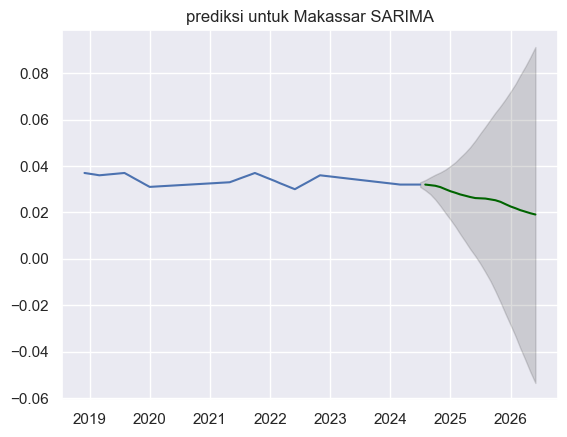

In [ ]:
# Forecast
n_periods = 24
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(data.index[-1], periods = n_periods, freq='MS')

# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# Plot
plt.plot(data)
plt.plot(fitted_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("prediksi untuk Makassar SARIMA")
plt.show()